In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import itertools as it
import scipy.stats.qmc as ssq
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from skopt import BayesSearchCV
from skopt.space.space import Real, Integer
from sklearn.preprocessing import MinMaxScaler, StandardScaler

np.set_printoptions(threshold=100_000)
X = pd.read_csv(r"C:\Users\dwigh\OneDrive\Desktop\Emissions Uncertainty on Antarctic Instability\ensemble_output\results\default\parameters.csv")

Y = pd.read_csv(r"C:\Users\dwigh\OneDrive\Desktop\Emissions Uncertainty on Antarctic Instability\ensemble_output\results\default\gmslr.csv")
Y = Y.mean(axis=1).rename('output')
obj = X.join(Y, how='left')
obj.sort_values(by='t_peak',ascending=True, inplace=True)


In [2]:
# obj.t_peak = pd.to_datetime(obj.t_peak, format='%Y')
obj.set_index('t_peak',drop=False, inplace=True)
obj

,gamma_g,t_peak,gamma_d,sd_temp,sd_ocean_heat,sd_glaciers,sd_greenland,sd_antarctic,sd_gmsl,rho_temperature,...,antarctic_kappa,antarctic_flow0,antarctic_runoff_height0,antarctic_c,antarctic_bed_height0,antarctic_slope,antarctic_lambda,antarctic_temp_threshold,lw_random_sample,output
t_peak,,,,,,,,,,,,,,,,,,,,,
2030.0,0.005979,2030.0,0.091974,0.074738,2.503238,0.000198,0.000232,0.000383,0.000405,0.467965,...,0.072566,1.072699,1240.514180,79.039386,762.770179,0.000707,0.008297,-15.740854,0.000261,0.430777
2030.0,0.009668,2030.0,0.081546,0.081082,1.851315,0.000132,0.000251,0.000502,0.001941,0.369884,...,0.076086,1.323465,1014.354512,126.821100,807.992695,0.000624,0.013372,-15.546083,0.000092,0.347866
2030.0,0.002629,2030.0,0.149528,0.082100,1.756363,0.000159,0.000247,0.000475,0.002613,0.506711,...,0.059001,1.328616,1737.814817,119.263273,809.343880,0.000708,0.006230,-15.540414,0.000242,0.365387
2030.0,0.003917,2030.0,0.081056,0.087278,2.841193,0.000082,0.000239,0.000466,0.001685,0.355840,...,0.054435,0.993865,1136.483270,140.548806,816.925800,0.000684,0.006855,-15.453124,0.000164,0.390832
2030.0,0.008057,2030.0,0.112075,0.077741,1.353660,0.000495,0.000276,0.000340,0.001981,0.538458,...,0.055346,1.470483,991.781103,97.797643,807.736344,0.000556,0.010325,-14.959565,0.000641,0.491800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2167.0,0.013229,2167.0,0.093814,0.080127,1.034033,0.000253,0.000202,0.000538,0.000763,0.518355,...,0.069314,1.460019,1379.251183,117.385686,797.296496,0.000668,0.011739,-16.190533,0.000739,3.135588
2169.0,0.003130,2169.0,0.022636,0.079961,2.088501,0.000069,0.000217,0.000380,0.001736,0.665597,...,0.065737,1.516385,1673.690577,136.186139,787.740252,0.000562,0.012827,-16.224729,0.000183,2.118476
2171.0,0.004158,2171.0,0.120120,0.078078,0.375789,0.000049,0.000264,0.000451,0.002437,0.763427,...,0.080312,0.812621,1340.939748,76.307069,798.575153,0.000548,0.009879,-15.795974,0.000354,2.240000


In [ ]:
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')
obj.output.plot(figsize=(15,5),color=color_pal[0], kind='kde')
plt.show()

In [3]:
def add_lags(data: pd.DataFrame):
    new_data = data.copy()
    index = pd.to_datetime(new_data.t_peak, format='%Y')
    target_map = new_data['output'].to_dict()
    lag1 =  (index - pd.Timedelta('3650 days')).dt.year
    lag2 = (index - pd.Timedelta('7300 days')).dt.year
    lag3 = (index - pd.Timedelta('10950 days')).dt.year
    lag4 = (index - pd.Timedelta('14600 days')).dt.year
    new_data['lag1'] = lag1.map(target_map)
    new_data['lag2'] = lag2.map(target_map)
    new_data['lag3'] = lag3.map(target_map)
    new_data['lag4'] = lag4.map(target_map)
    return new_data

In [4]:
new_obj = add_lags(obj)
new_obj

,gamma_g,t_peak,gamma_d,sd_temp,sd_ocean_heat,sd_glaciers,sd_greenland,sd_antarctic,sd_gmsl,rho_temperature,...,antarctic_bed_height0,antarctic_slope,antarctic_lambda,antarctic_temp_threshold,lw_random_sample,output,lag1,lag2,lag3,lag4
t_peak,,,,,,,,,,,,,,,,,,,,,
2030.0,0.005979,2030.0,0.091974,0.074738,2.503238,0.000198,0.000232,0.000383,0.000405,0.467965,...,762.770179,0.000707,0.008297,-15.740854,0.000261,0.430777,NaN,NaN,NaN,NaN
2030.0,0.009668,2030.0,0.081546,0.081082,1.851315,0.000132,0.000251,0.000502,0.001941,0.369884,...,807.992695,0.000624,0.013372,-15.546083,0.000092,0.347866,NaN,NaN,NaN,NaN
2030.0,0.002629,2030.0,0.149528,0.082100,1.756363,0.000159,0.000247,0.000475,0.002613,0.506711,...,809.343880,0.000708,0.006230,-15.540414,0.000242,0.365387,NaN,NaN,NaN,NaN
2030.0,0.003917,2030.0,0.081056,0.087278,2.841193,0.000082,0.000239,0.000466,0.001685,0.355840,...,816.925800,0.000684,0.006855,-15.453124,0.000164,0.390832,NaN,NaN,NaN,NaN
2030.0,0.008057,2030.0,0.112075,0.077741,1.353660,0.000495,0.000276,0.000340,0.001981,0.538458,...,807.736344,0.000556,0.010325,-14.959565,0.000641,0.491800,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2167.0,0.013229,2167.0,0.093814,0.080127,1.034033,0.000253,0.000202,0.000538,0.000763,0.518355,...,797.296496,0.000668,0.011739,-16.190533,0.000739,3.135588,1.850573,1.986589,1.779445,1.878773
2169.0,0.003130,2169.0,0.022636,0.079961,2.088501,0.000069,0.000217,0.000380,0.001736,0.665597,...,787.740252,0.000562,0.012827,-16.224729,0.000183,2.118476,1.955840,2.079071,1.814394,2.288148
2171.0,0.004158,2171.0,0.120120,0.078078,0.375789,0.000049,0.000264,0.000451,0.002437,0.763427,...,798.575153,0.000548,0.009879,-15.795974,0.000354,2.240000,1.412102,1.180434,2.106782,1.662140


In [5]:
new_obj1 = new_obj.copy()
output = new_obj1.pop('output')
new_obj1.insert(57, 'output', output)

In [26]:
val = TimeSeriesSplit(n_splits=4, max_train_size=60_000)
features = new_obj1.iloc[:,:-1].columns
target = new_obj1.iloc[:,-1].name
scores = {'Train Error':list(), 'Test Error': list()}
folds = 0
for train_indx, val_indx in val.split(new_obj1):
    train = new_obj1.iloc[train_indx]
    test = new_obj1.iloc[val_indx]

    X_train = train[features]
    Y_train = train[target]
    X_test = test[features]
    Y_test = test[target]
    RF = RandomForestRegressor(n_estimators=286, max_depth=74, max_features=41, n_jobs=10, random_state=0)
    RF.fit(X_train, Y_train)
    y_pred = RF.predict(X_train)
    y_tpred = RF.predict(X_test)
    val_error = np.square(Y_test - y_tpred).mean()
    train_error = np.square(Y_train - y_pred).mean()
    print(f'[{folds}]Training MSE:\t{train_error} Validation MSE:\t{val_error}')
    scores['Train Error'].append(train_error)
    scores['Test Error'].append(val_error)
    folds+=1
print(f'Mean Training MSE\t{sum(scores['Train Error'])/len(scores['Train Error'])}')
print(f'Mean Testing MSE:\t{sum(scores['Test Error'])/len(scores['Test Error'])}')

[0]Training MSE:	0.0016570126724221978 Validation MSE:	0.06508006801365152
[1]Training MSE:	0.0018953642984000684 Validation MSE:	0.06537075533329914
[2]Training MSE:	0.0020675237970000145 Validation MSE:	0.06699506043233368
[3]Training MSE:	0.002396089353463513 Validation MSE:	0.11086271583793823
Mean Training MSE	0.002003997530321448
Mean Testing MSE:	0.07707714990430564


In [6]:
val1 = train_test_split(new_obj1.iloc[:,:-1], new_obj1.iloc[:,-1], shuffle=False,train_size=0.8, random_state=0)
RF = RandomForestRegressor(n_estimators=286, max_depth=74, max_features=41, n_jobs=15, random_state=0)
RF.fit(val1[0],val1[2])

RandomForestRegressor(max_depth=74, max_features=41, n_estimators=286,
                      n_jobs=15, random_state=0)

In [7]:
RF.feature_importances_

array([0.03971179, 0.22415782, 0.1571004 , 0.00173949, 0.00170928,
       0.00173483, 0.00184963, 0.00209198, 0.00187658, 0.0017976 ,
       0.00171064, 0.00170994, 0.00239015, 0.00176343, 0.0023427 ,
       0.00176511, 0.00175243, 0.00229026, 0.00217592, 0.00173793,
       0.00177699, 0.00182637, 0.00166631, 0.00169621, 0.00567953,
       0.00197531, 0.00234556, 0.0020328 , 0.02940605, 0.16317479,
       0.00221899, 0.00325813, 0.00426266, 0.00226327, 0.00478749,
       0.00166873, 0.00174315, 0.00206303, 0.00167349, 0.00173564,
       0.00177704, 0.00602143, 0.0017868 , 0.00253355, 0.00180116,
       0.00195955, 0.00209827, 0.00181181, 0.0016922 , 0.00165124,
       0.08568481, 0.12000562, 0.0029787 , 0.00421434, 0.01295254,
       0.01990569, 0.04046285])

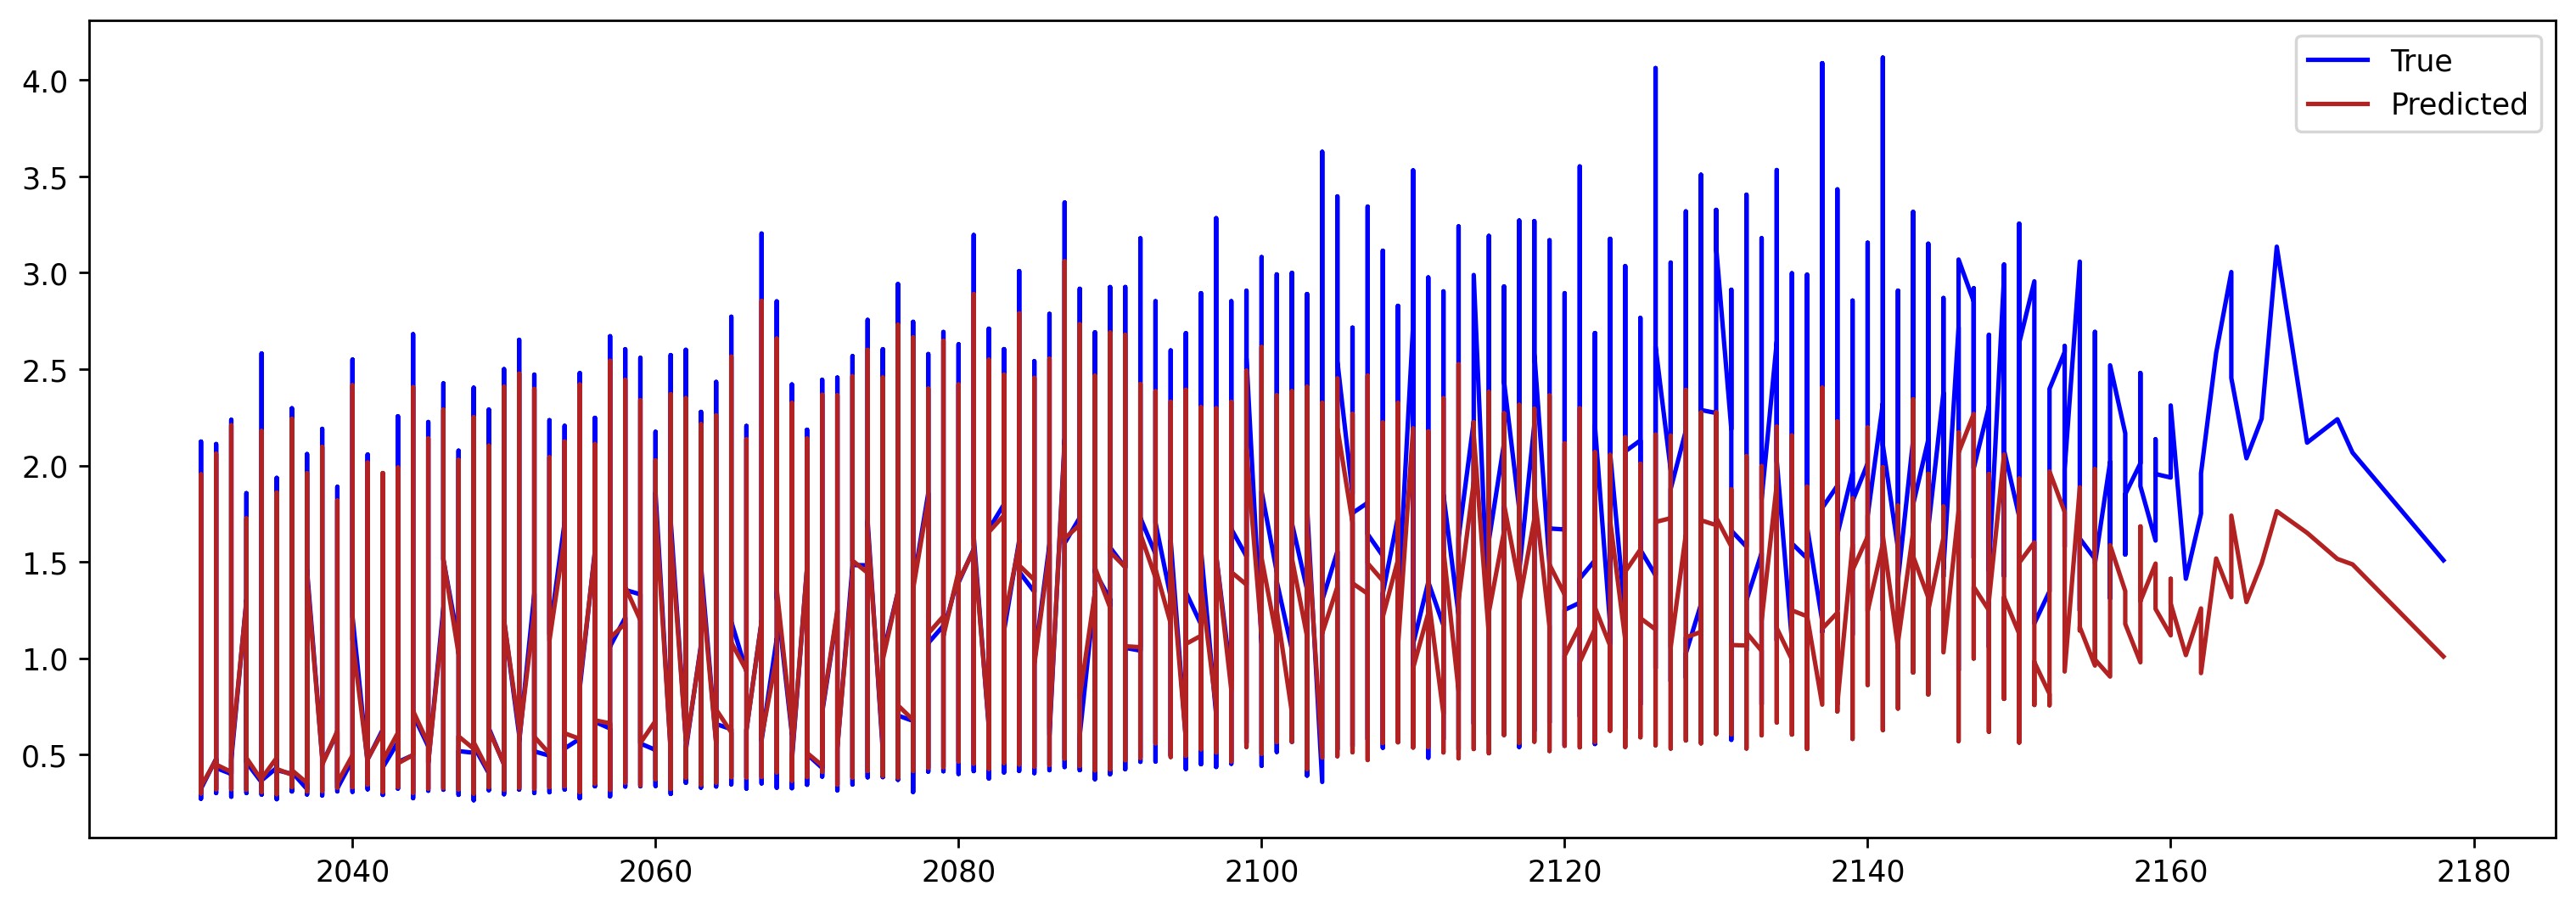

In [8]:
fig, ax = plt.subplots(1,1, figsize=(15,5), dpi=250)
ax.plot(new_obj1.t_peak, new_obj1.output, color='blue', label='True')
ax.plot(new_obj1.t_peak, RF.predict(new_obj1.iloc[:,:-1]), color='firebrick', label='Predicted')
ax.legend()
plt.show()

In [9]:
def mod_pvi1(data: pd.DataFrame, y_true: np.ndarray[float], f: callable,*, n_boots: int, alpha: float, column_set: dict) -> tuple[pd.DataFrame]:
    rows, columns = data.shape
    npv_columns = column_set
    V_y = np.var(y_true, ddof=1)
    u = dict()
    CI = dict()
    rolled_data = pd.DataFrame(np.roll(data.copy(),rows//2, axis=0), columns=data.columns)
    # rolled_data = np.roll(data.copy(), rows//2, axis=0)
    for col in npv_columns:
        d = rolled_data.copy()
        d[col] = data[col].to_numpy()
        y_pred = f(d)
        u[col] = 1-np.mean(np.square(y_true - y_pred))/(2*V_y)
        S_CI = 1 - bootstrapp(y_true,y_pred, n_boots)/(2*V_y)
        p0,p1 = np.quantile(S_CI, [alpha,1-alpha])
        CI[col] = [p0,p1,p1-p0]
    CI = pd.DataFrame(CI.values(), index = CI.keys(), columns=['5th','95th','Quantile Difference'])
    CI.index.name = 'Interactions'
    CI.columns.name = 'Confidence Interval Difference'
    SI = pd.DataFrame(u.values(), index=u.keys(), columns=['$P_{i}$'])
    return u,CI

In [10]:
def mod_pvi_t(data: np.ndarray[float], y_true: np.ndarray[float], f: callable,*,n_boots: int, alpha: float, column_set: list[str]) -> np.ndarray[float]:
    '''
    ===Total-Order Permutation Variable Importances===

        data: your training dataset
        y_pred: your model output (specifically the prediction of your 'data' arg)
        f: in this case, simply RF.predict
    '''
    rows, columns = data.shape
    npv_columns = column_set
    u = dict()
    V_y = np.var(y_true,ddof=1 )
    CI = dict()
    for col in npv_columns:
        d = data.copy()
        d[col] = np.roll(data[col],rows//2, axis=0)
        y_pred = f(d)
        u[col] = np.mean(np.square(y_true - y_pred))/(2*V_y)
        S_CI = bootstrapp(y_true,y_pred, n_boots)/(2*V_y)
        p0,p1 = np.quantile(S_CI, [alpha,1-alpha])
        CI[col] = [p0,p1,p1-p0]
    CI = pd.DataFrame(CI.values(), index = CI.keys(), columns=['5th','95th','Quantile Difference'])
    CI.index.name = 'Interactions'
    CI.columns.name = 'Confidence Interval Difference'
    S_t = pd.DataFrame(u.values(), index=u.keys(), columns=[r'$P_{\tau}$'])
    return u, CI

In [11]:
PI, CI = mod_pvi1(val1[0], val1[2], RF.predict, n_boots=1000, alpha=0.05, column_set=val1[0].columns)

NameError: name 'bootstrapp' is not defined